# Train-Free Segmentation in MRI with Cubical Persistent Homology
## Myocardium segmentation

Anton François & Raphaël Tinarrage

See the repo at https://github.com/antonfrancois/gliomaSegmentation_TDA and article at https://arxiv.org/abs/2401.01160

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from segmentations import parseACDC, segment_cardiac
from utils import get_multiple_dice, DLT_KW_SEG

## Open an image

In [2]:
# Open a specific image.
n_image = 103  # between 1 and 150 included
modality = "ED"  # can be 'ED or 'ES' (end diastole, end systole)
img, seg_gt = parseACDC(n_image, end=modality)

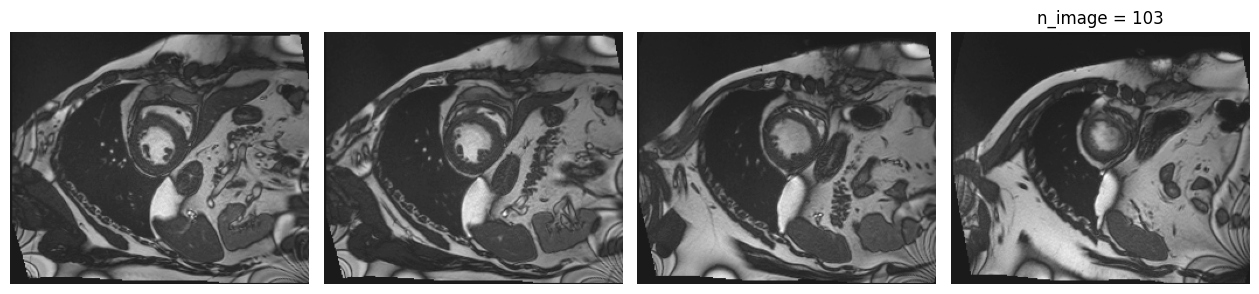

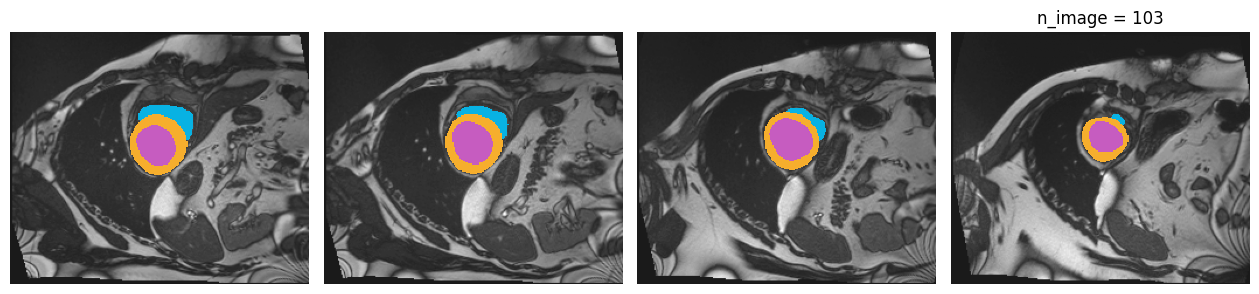

In [3]:
# Plot several coronal slices.
z_pos = [int(i) for i in np.linspace(2, np.shape(img)[2] - 2, 4)]
figsize = (len(z_pos) * 4, 4)
fig = plt.figure(figsize=figsize)
fig.subplots_adjust(wspace=0.05, hspace=0)
for i in range(len(z_pos)):
    ax = fig.add_subplot(1, len(z_pos), i + 1)
    ax.axis("off")
    ax.imshow(img[:, :, z_pos[i]], cmap="gray", alpha=0.9, origin="upper")
ax.set_title("n_image = " + repr(n_image))
plt.show()

# Plot several coronal slices with ground-truth segmentation.
z_pos = [int(i) for i in np.linspace(2, np.shape(img)[2] - 2, 4)]
figsize = (len(z_pos) * 4, 4)
fig = plt.figure(figsize=figsize)
fig.subplots_adjust(wspace=0.05, hspace=0)
for i in range(len(z_pos)):
    ax = fig.add_subplot(1, len(z_pos), i + 1)
    ax.axis("off")
    ax.imshow(img[:, :, z_pos[i]], cmap="gray", alpha=0.9, origin="upper")
    ax.imshow(seg_gt[:, :, z_pos[i]], **DLT_KW_SEG)
ax.set_title("n_image = " + repr(n_image))
plt.show()

## Full segmentation
Two methods are implemented: either "2D" (segmentation slice by slice) or "3D" (segmentation form the whole CMR). The 2D method offers better scores.

In [4]:
# Parameters for the algorithm.
sigma = 1  # preprocess_cardiac, Gaussian blur
radius_dilation = 0  # preprocess_cardiac, dilation parameter
dt_threshold = 1.0  # segment_whole_object_cardiac, threshold for suggest_t
H0_features_max = 10  # segment_whole_object_cardiac, number of H2 bars to consider
thresh_small_LV = 200  # segment_whole_object_cardiac, minimal width of LV
ratio_small_RV = 0.1  # segment_whole_object_cardiac, minimal width of RV compared to LV
ratio_big_RV = 5  # segment_whole_object_cardiac, maximal width of RV, compared to LV
add_to_iterations = 2  # segment_whole_object_cardiac, fill gap between LV and RV
maximal_distance = np.inf  # segment_whole_object_cardiac, max dist between LV and RV

### Segmentation in 2D

In [5]:
# Segmentation 2D.
method = "2D"
seg_final = segment_cardiac(img=img, seg_gt=seg_gt, method=method, sigma=sigma, radius_dilation=radius_dilation,
                            dt_threshold=dt_threshold, H0_features_max=H0_features_max, thresh_small_LV=thresh_small_LV,
                            ratio_small_RV=ratio_small_RV, ratio_big_RV=ratio_big_RV,
                            add_to_iterations=add_to_iterations, maximal_distance=maximal_distance, verbose=False,
                            plot=False, )

In [6]:
# Print scores.
_ = get_multiple_dice(seg_final[:, :, 1:-1], seg_gt[:, :, 1:-1], labels=(1, 2, 3), verbose=True)

Sørensen–Dice coefficients: {1: np.float64(0.6), 2: np.float64(0.689), 3: np.float64(0.926)} - Whole: 0.859


Sørensen–Dice coefficients: {1: np.float64(0.6), 2: np.float64(0.689), 3: np.float64(0.926)} - Whole: 0.859

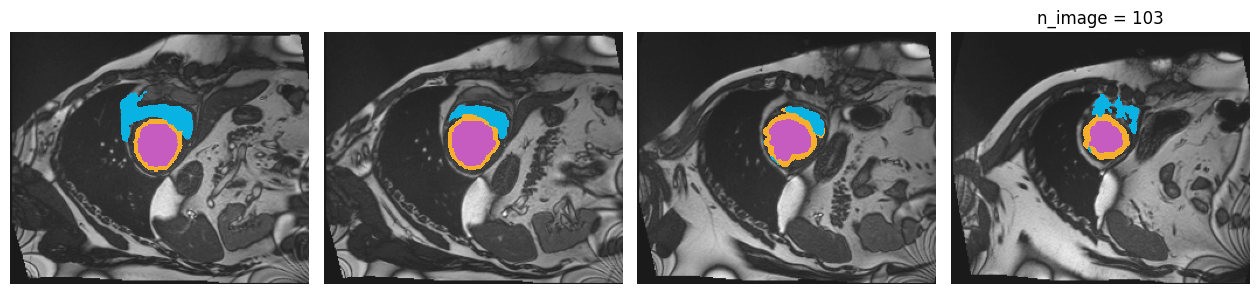

In [7]:
# Plot several coronal slices.
z_pos = [int(i) for i in np.linspace(2, np.shape(img)[2] - 2, 4)]
figsize = (len(z_pos) * 4, 4)
fig = plt.figure(figsize=figsize)
fig.subplots_adjust(wspace=0.05, hspace=0)
for i in range(len(z_pos)):
    ax = fig.add_subplot(1, len(z_pos), i + 1)
    ax.axis("off")
    ax.imshow(img[:, :, z_pos[i]], cmap="gray", alpha=0.9, origin="upper")
    ax.imshow(seg_final[:, :, z_pos[i]], **DLT_KW_SEG)
ax.set_title("n_image = " + repr(n_image))
plt.show()

### Segmentation in 3D

In [8]:
# Segment in 3D
method = "3D"
seg_final = segment_cardiac(img=img, seg_gt=seg_gt, method=method, sigma=sigma, radius_dilation=radius_dilation,
                            dt_threshold=dt_threshold, H0_features_max=H0_features_max, thresh_small_LV=thresh_small_LV,
                            ratio_small_RV=ratio_small_RV, ratio_big_RV=ratio_big_RV,
                            add_to_iterations=add_to_iterations, maximal_distance=maximal_distance, verbose=False,
                            plot=False, )

In [9]:
# Print scores.
_ = get_multiple_dice(seg_final[:, :, 1:-1], seg_gt[:, :, 1:-1], labels=(1, 2, 3), verbose=True)

Sørensen–Dice coefficients: {1: np.float64(0.537), 2: np.float64(0.682), 3: np.float64(0.912)} - Whole: 0.803


Sørensen–Dice coefficients: {1: np.float64(0.537), 2: np.float64(0.682), 3: np.float64(0.912)} - Whole: 0.803

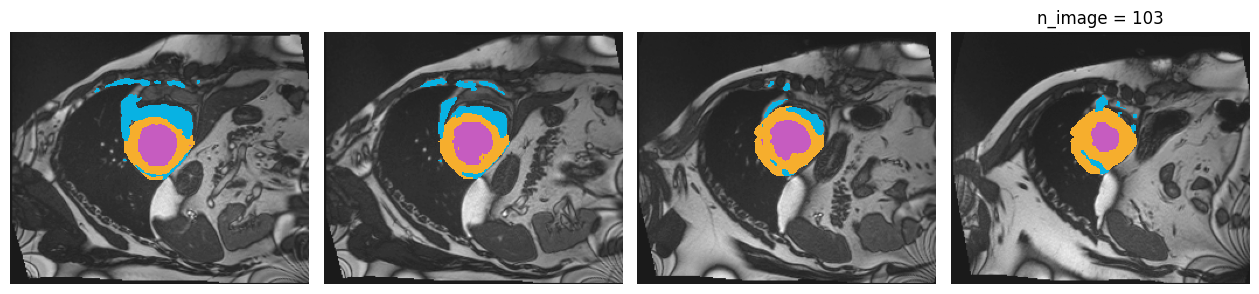

In [10]:
# Plot several coronal slices.
z_pos = [int(i) for i in np.linspace(2, np.shape(img)[2] - 2, 4)]
figsize = (len(z_pos) * 4, 4)
fig = plt.figure(figsize=figsize)
fig.subplots_adjust(wspace=0.05, hspace=0)
for i in range(len(z_pos)):
    ax = fig.add_subplot(1, len(z_pos), i + 1)
    ax.axis("off")
    ax.imshow(img[:, :, z_pos[i]], cmap="gray", alpha=0.9, origin="upper")
    ax.imshow(seg_final[:, :, z_pos[i]], **DLT_KW_SEG)
ax.set_title("n_image = " + repr(n_image))
plt.show()

## Segmentation step by step
We now illustrate the slice-by-slice slicing, implicitly used in `segment_cardiac()` of the previous cells, for the `2D` method.

In [10]:
from segmentations import preprocess_cardiac, segment_whole_object_cardiac, segment_geometric_object_cardiac, \
    segment_other_components_cardiac

In [11]:
# Preprocess.
img = preprocess_cardiac(img=img, sigma=sigma, radius_dilation=radius_dilation)

Slice 1 out of 9


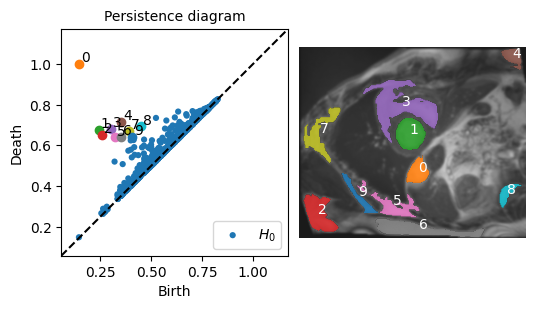

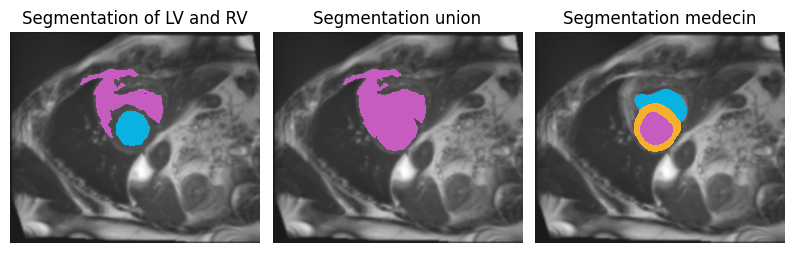

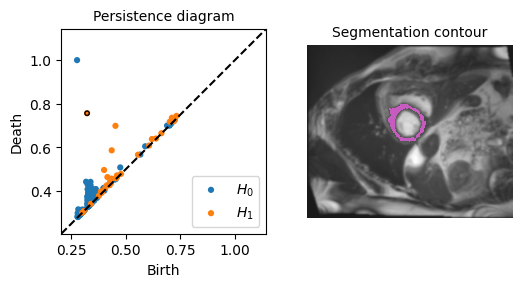

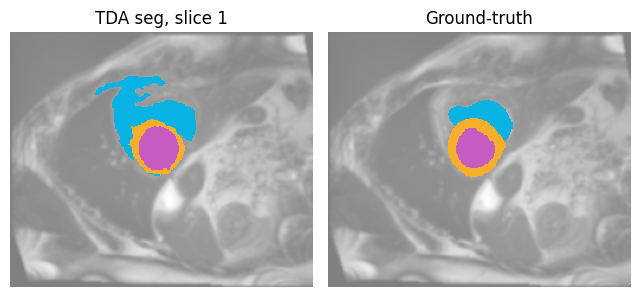

Slice 2 out of 9


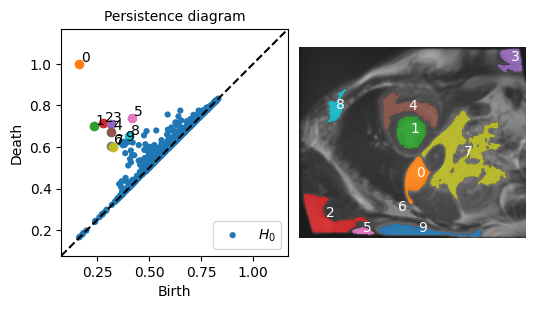

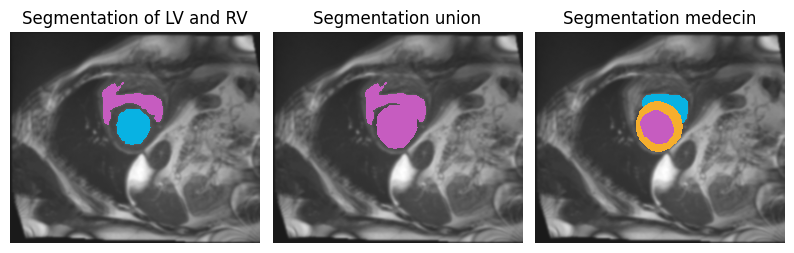

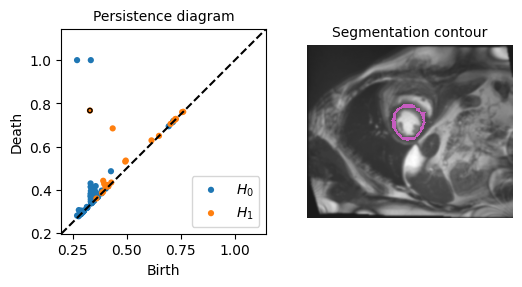

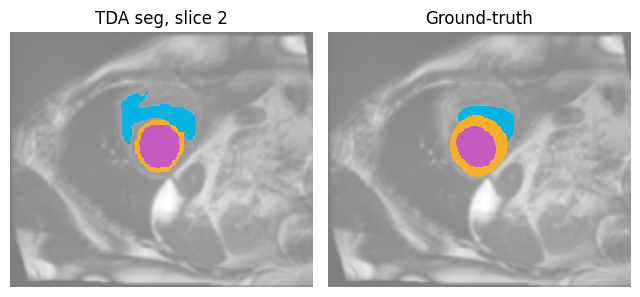

Slice 3 out of 9


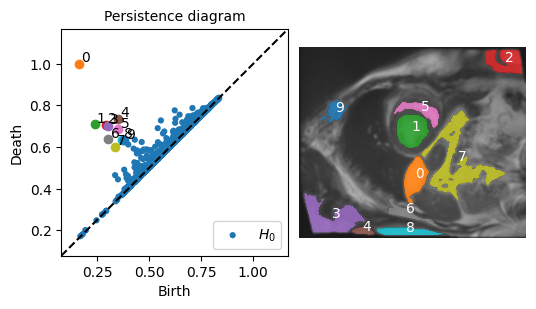

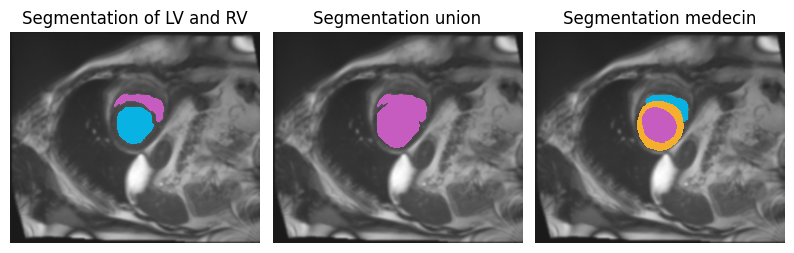

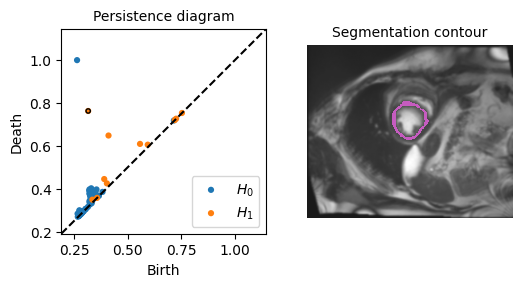

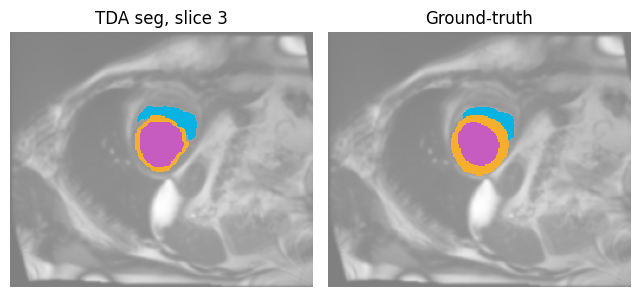

Slice 4 out of 9


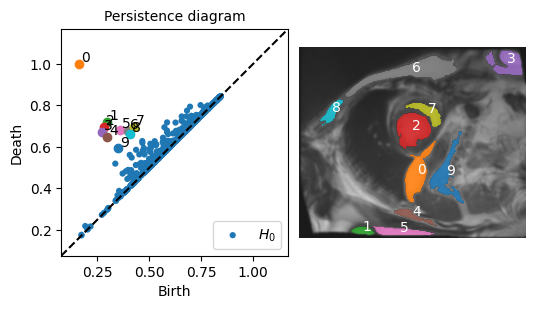

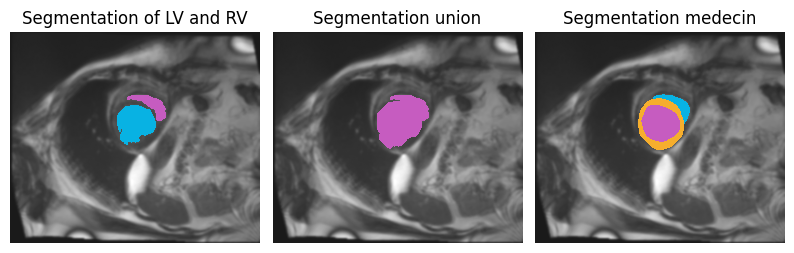

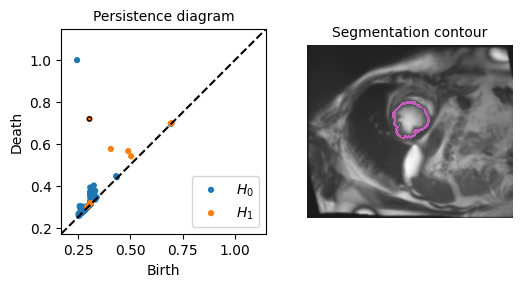

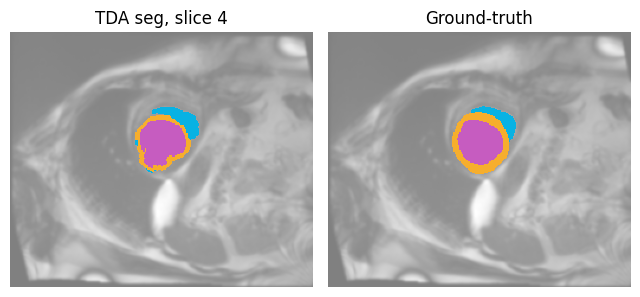

Slice 5 out of 9


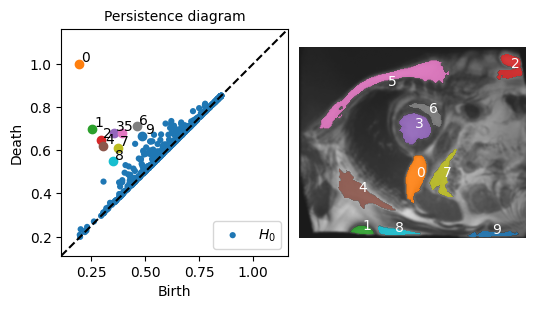

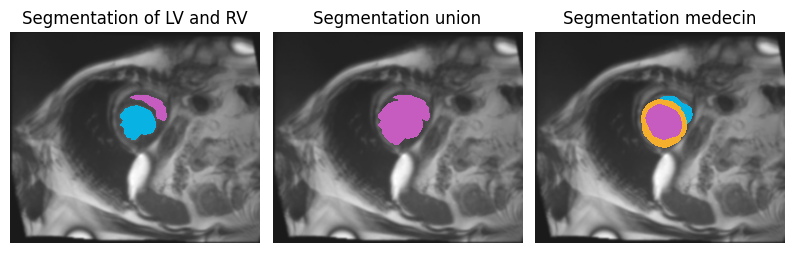

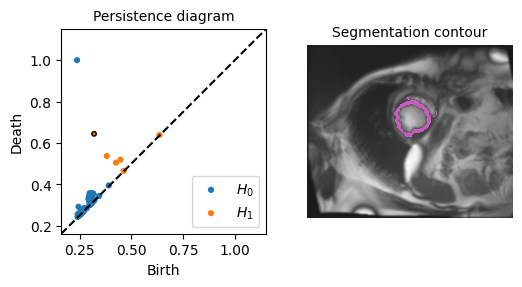

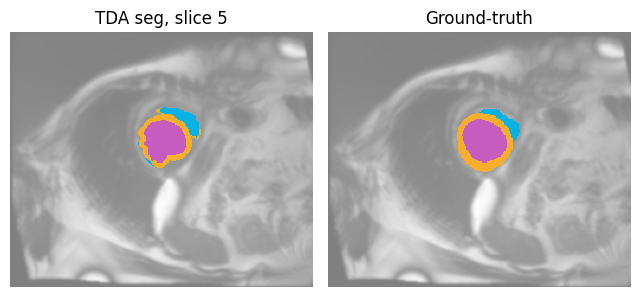

Slice 6 out of 9


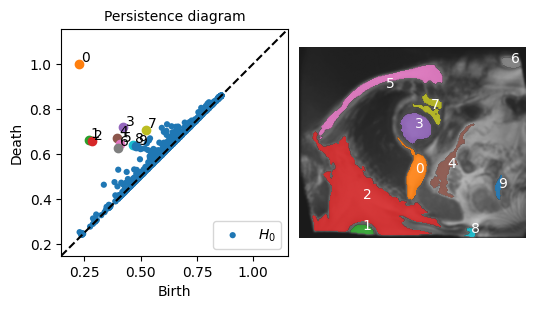

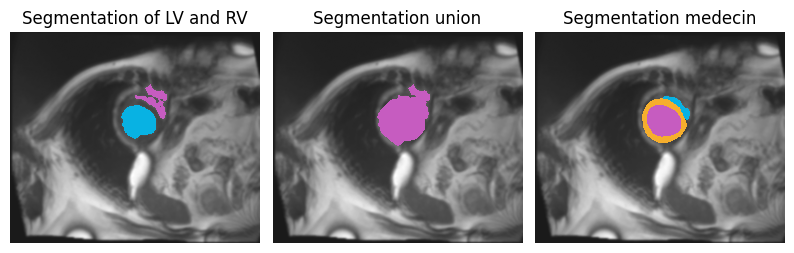

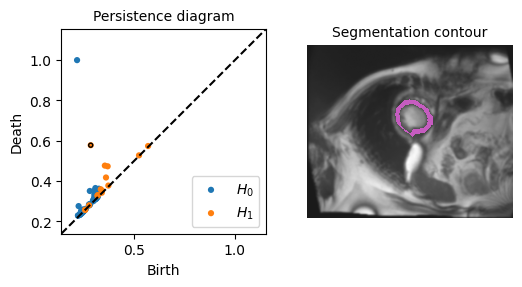

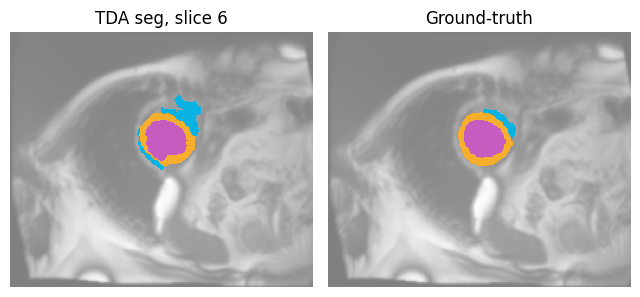

Slice 7 out of 9


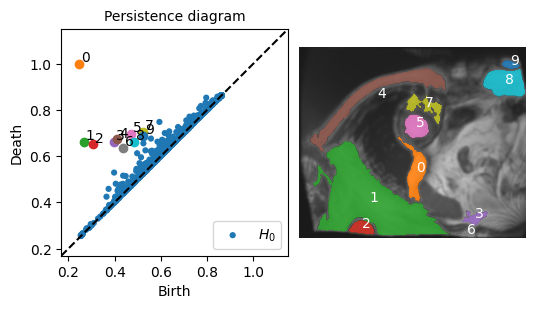

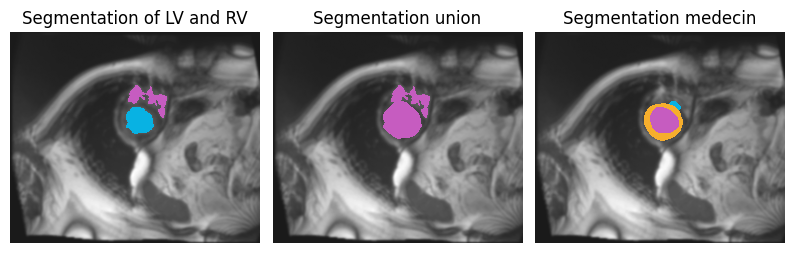

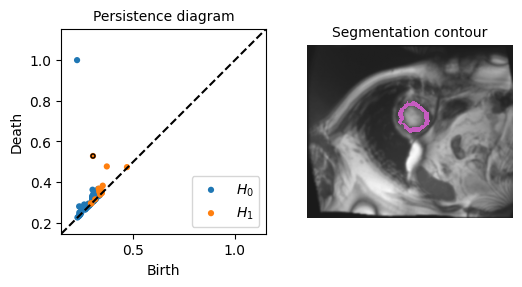

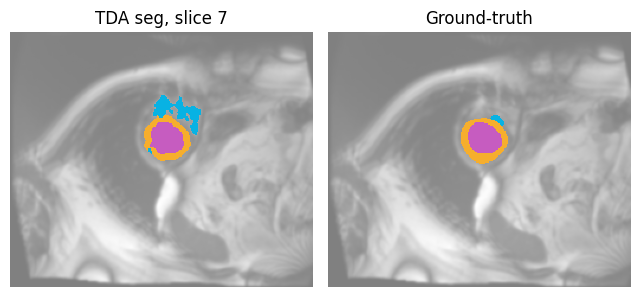

Slice 8 out of 9


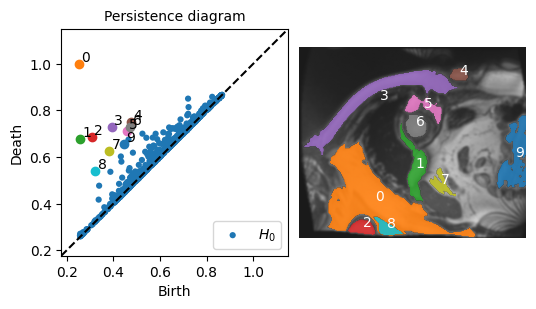

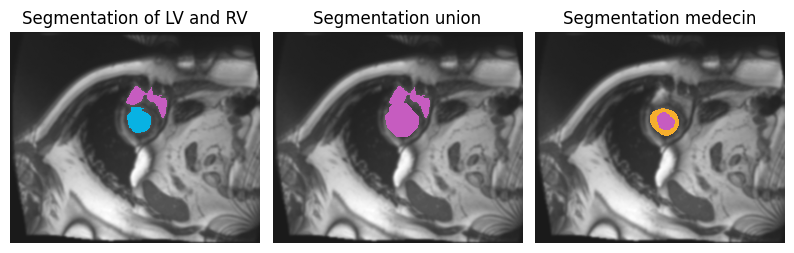

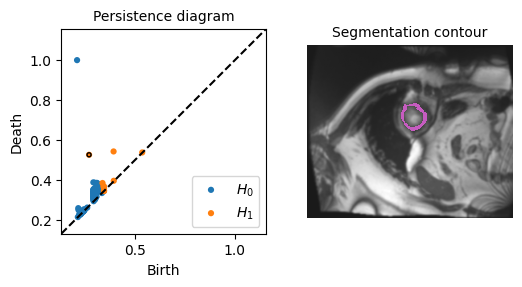

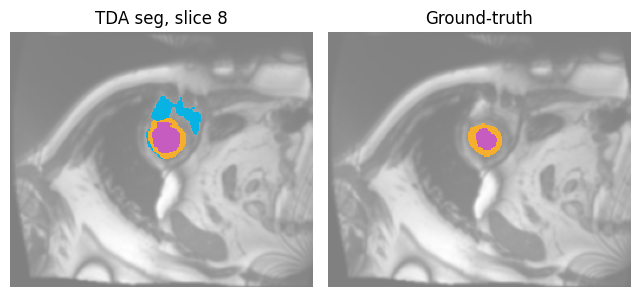

In [12]:
# Segment 2D (slice by slice)

verbose, plot, plot_slice = False, True, True

seg_final = np.zeros(np.shape(img))
for z_pos in range(1, np.shape(img)[2]):
    print(f"Slice {z_pos} out of {np.shape(img)[2]}")
    # Take a slice.
    img_slice, seg_gt_slice = img[:, :, z_pos], seg_gt[:, :, z_pos]
    # Segment whole object.
    seg_whole_slice = segment_whole_object_cardiac(img=img_slice, seg_gt=seg_gt_slice, H0_features_max=H0_features_max,
                                                   dt_threshold=dt_threshold, thresh_small_LV=thresh_small_LV,
                                                   ratio_small_RV=ratio_small_RV, ratio_big_RV=ratio_big_RV,
                                                   radius_dilation=radius_dilation, add_to_iterations=add_to_iterations,
                                                   maximal_distance=maximal_distance, verbose=verbose, plot=plot, )
    # Segment geometric object.
    seg_geom_slice = segment_geometric_object_cardiac(img_slice, seg_whole_slice, verbose=verbose, plot=plot)
    # Deduce components.
    seg_final_slice = segment_other_components_cardiac(seg_whole_slice, seg_geom_slice, verbose=verbose)
    seg_final[:, :, z_pos] = seg_final_slice
    # Plot and comment.
    if plot_slice:
        fig = plt.figure(figsize=(8, 4))
        fig.subplots_adjust(wspace=0.05, hspace=0)
        ax = fig.add_subplot(1, 2, 1)
        ax.axis("off")
        ax.set_title("TDA seg, slice " + repr(z_pos))
        ax.imshow(img_slice, cmap="gray", alpha=0.5, origin="upper")
        ax.imshow(seg_final_slice, **DLT_KW_SEG)
        ax = fig.add_subplot(1, 2, 2)
        ax.axis("off")
        ax.set_title("Ground-truth")
        ax.imshow(img_slice, cmap="gray", alpha=0.5, origin="upper")
        ax.imshow(seg_gt_slice, **DLT_KW_SEG)
        plt.show()